# Function-level LM-CC results

All metrics computed on the **gold patch's target function** (outermost top-level def/method). Mirrors `swe_bench_whole_file_results.ipynb`: a single-model (Agentless Claude-3.5-Sonnet `resolved`) section first, then the all-agents resolution-rate analysis.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

from src.config import PATHS
import pandas as pd

metrics_df = pd.read_parquet(PATHS.FUNCTION_RESULT_DATASET)
labeled_df = pd.read_parquet(PATHS.LABELED_DATASET)
difficulty = pd.read_parquet(PATHS.TASK_DIFFICULTY)

merged = (
    metrics_df
    .merge(labeled_df[['instance_id', 'resolved']], on='instance_id', how='left')
    .merge(difficulty[['instance_id', 'resolution_rate']], on='instance_id', how='left')
)

clean = merged[
    merged['has_patched_function'].fillna(False)
    & merged['parsable'].fillna(False)
    & merged['lm_cc_score'].notna()
    & merged['resolved'].notna()
].copy()

print(f'Total tasks:            {len(merged)}')
print(f'With patched function:  {int(merged["has_patched_function"].fillna(False).sum())}')
print(f'Excluded (no function): {int((~merged["has_patched_function"].fillna(False)).sum())}')
print(f'Usable (clean):         {len(clean)}')
print(f'Resolve rate:           {clean["resolved"].mean():.1%}')


Total tasks:            427
With patched function:  411
Excluded (no function): 16
Usable (clean):         411
Resolve rate:           56.7%


## LM-CC distribution

count     411.000000
mean      166.253041
std       223.821984
min         3.000000
25%        41.800000
50%        93.800000
75%       208.700000
max      2843.400000
Name: lm_cc_score, dtype: float64


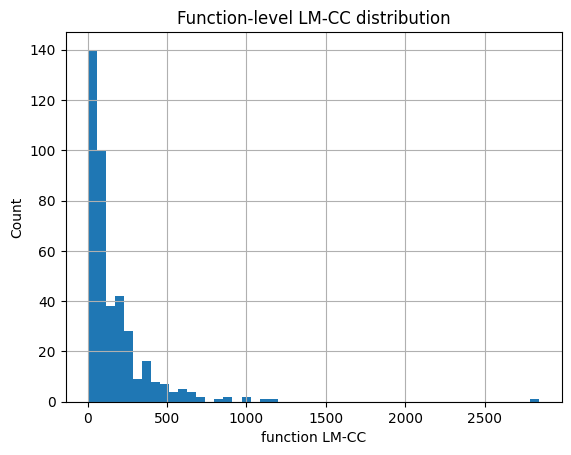

In [2]:
import matplotlib.pyplot as plt

print(clean['lm_cc_score'].describe())
clean['lm_cc_score'].hist(bins=50)
plt.xlabel('function LM-CC'); plt.ylabel('Count')
plt.title('Function-level LM-CC distribution')
plt.show()


## Correlation table — metrics vs. `resolved`

Zero-order and LOC-controlled (sample + subgroup) Spearman correlations, mirroring the paper's Table 2.

In [3]:
from src.correlation import full_correlation_table

metrics_to_compare = [
    'cc_avg', 'cc_max', 'cc_sum',
    'halstead_volume', 'halstead_difficulty', 'halstead_effort',
    'loc', 'lloc', 'nesting_max', 'n_tokens_meaningful', 'n_functions', 'n_branches',
    'lm_cc_max_comp', 'lm_cc_avg_comp', 'lm_cc_total_comp',
    'lm_cc_max_branch', 'lm_cc_avg_branch', 'lm_cc_total_branch',
    'lm_cc_score',
]
available_metrics = [m for m in metrics_to_compare if m in clean.columns]
result_table = full_correlation_table(clean, available_metrics)
print('=== Function-level: Full Correlation Table (vs. resolved) ===')
print(result_table.to_string(index=False))


=== Function-level: Full Correlation Table (vs. resolved) ===
             metric      sample_zero sample_partial_loc          subgroup_zero   subgroup_partial_loc
             cc_avg +0.011 (p=0.828)   +0.092 (p=0.064) -0.250 (p=0.516, n=10)  +0.139 (p=0.755, n=9)
             cc_max -0.001 (p=0.985)   +0.095 (p=0.055) +0.133 (p=0.732, n=10) +0.193 (p=0.661, n=10)
             cc_sum -0.037 (p=0.454)   +0.045 (p=0.368)  -0.218 (p=0.574, n=9) -0.000 (p=1.000, n=10)
    halstead_volume -0.031 (p=0.532)   +0.052 (p=0.296)  -0.167 (p=0.668, n=9) +0.233 (p=0.561, n=11)
halstead_difficulty -0.024 (p=0.622)   +0.057 (p=0.249)  -0.367 (p=0.332, n=9) -0.366 (p=0.391, n=10)
    halstead_effort -0.028 (p=0.572)   +0.056 (p=0.254)  -0.285 (p=0.458, n=9)  -0.238 (p=0.588, n=9)
                loc -0.068 (p=0.168)                  — -0.273 (p=0.446, n=10)                      —
               lloc -0.065 (p=0.186)   +0.037 (p=0.455) -0.345 (p=0.328, n=10) -0.000 (p=1.000, n=10)
        nesting_max 

In [4]:
classical = ['cc_avg', 'cc_max', 'cc_sum', 'halstead_volume', 'halstead_difficulty',
             'halstead_effort', 'loc', 'lloc', 'nesting_max', 'n_tokens_meaningful',
             'n_functions', 'n_branches']
lm_cc_components = ['lm_cc_max_comp', 'lm_cc_avg_comp', 'lm_cc_total_comp',
                    'lm_cc_max_branch', 'lm_cc_avg_branch', 'lm_cc_total_branch']
lm_cc_final = ['lm_cc_score']

for title, group in [('Classic metrics', classical),
                     ('LM-CC sub-features', lm_cc_components),
                     ('LM-CC (composite)', lm_cc_final)]:
    print('=' * 92); print(title); print('=' * 92)
    print(result_table[result_table['metric'].isin(group)].to_string(index=False)); print()


Classic metrics
             metric      sample_zero sample_partial_loc          subgroup_zero   subgroup_partial_loc
             cc_avg +0.011 (p=0.828)   +0.092 (p=0.064) -0.250 (p=0.516, n=10)  +0.139 (p=0.755, n=9)
             cc_max -0.001 (p=0.985)   +0.095 (p=0.055) +0.133 (p=0.732, n=10) +0.193 (p=0.661, n=10)
             cc_sum -0.037 (p=0.454)   +0.045 (p=0.368)  -0.218 (p=0.574, n=9) -0.000 (p=1.000, n=10)
    halstead_volume -0.031 (p=0.532)   +0.052 (p=0.296)  -0.167 (p=0.668, n=9) +0.233 (p=0.561, n=11)
halstead_difficulty -0.024 (p=0.622)   +0.057 (p=0.249)  -0.367 (p=0.332, n=9) -0.366 (p=0.391, n=10)
    halstead_effort -0.028 (p=0.572)   +0.056 (p=0.254)  -0.285 (p=0.458, n=9)  -0.238 (p=0.588, n=9)
                loc -0.068 (p=0.168)                  — -0.273 (p=0.446, n=10)                      —
               lloc -0.065 (p=0.186)   +0.037 (p=0.455) -0.345 (p=0.328, n=10) -0.000 (p=1.000, n=10)
        nesting_max -0.018 (p=0.715)   +0.052 (p=0.291)  -0.200 (p

## Extreme cases — high / low LM-CC by resolution

In [5]:
cols = ['instance_id', 'lm_cc_score', 'loc', 'cc_sum', 'nesting_max']
print('=== High LM-CC, resolved ===')
print(clean[clean['resolved'] == 1].nlargest(5, 'lm_cc_score')[cols].to_string(index=False))
print('\n=== High LM-CC, not resolved ===')
print(clean[clean['resolved'] == 0].nlargest(5, 'lm_cc_score')[cols].to_string(index=False))
print('\n=== Low LM-CC, resolved ===')
print(clean[clean['resolved'] == 1].nsmallest(5, 'lm_cc_score')[cols].to_string(index=False))
print('\n=== Low LM-CC, not resolved ===')
print(clean[clean['resolved'] == 0].nsmallest(5, 'lm_cc_score')[cols].to_string(index=False))


=== High LM-CC, resolved ===
                     instance_id  lm_cc_score   loc  cc_sum  nesting_max
    matplotlib__matplotlib-13989       1123.6 204.0    88.0          6.0
    matplotlib__matplotlib-26113        998.6 163.0    37.0          3.0
              sympy__sympy-18189        714.4 131.0    53.0          8.0
              sympy__sympy-23824        672.2 149.0    67.0          6.0
scikit-learn__scikit-learn-11310        641.2  83.0    26.0          4.0

=== High LM-CC, not resolved ===
                     instance_id  lm_cc_score   loc  cc_sum  nesting_max
            django__django-15957       2843.4 439.0    17.0          5.0
              sympy__sympy-12489       1152.8 312.0   110.0          7.0
            django__django-15280        977.6 180.0     6.0          5.0
scikit-learn__scikit-learn-14087        902.4 121.0    39.0          3.0
    matplotlib__matplotlib-20488        878.2 122.0    38.0          4.0

=== Low LM-CC, resolved ===
         instance_id  lm_cc_scor

## LM-CC: resolved vs. not resolved

In [6]:
from scipy.stats import mannwhitneyu

resolved_lmcc = clean[clean['resolved'] == 1]['lm_cc_score']
failed_lmcc = clean[clean['resolved'] == 0]['lm_cc_score']
print('LM-CC on resolved tasks:')
print(f'  median {resolved_lmcc.median():.1f}, mean {resolved_lmcc.mean():.1f}')
print('LM-CC on not-resolved tasks:')
print(f'  median {failed_lmcc.median():.1f}, mean {failed_lmcc.mean():.1f}')
print(f'\nMann-Whitney-U: p = {mannwhitneyu(resolved_lmcc, failed_lmcc).pvalue:.3f}')


LM-CC on resolved tasks:
  median 95.2, mean 147.5
LM-CC on not-resolved tasks:
  median 92.0, mean 190.8

Mann-Whitney-U: p = 0.198


## Collinearity with LOC

In [7]:
from scipy.stats import spearmanr

metrics = ['lm_cc_score', 'lm_cc_total_comp', 'lm_cc_total_branch',
           'cc_sum', 'halstead_volume', 'lloc', 'nesting_max', 'n_branches']
print(f'{"Metric":<22} {"rho with LOC":>12}')
for m in metrics:
    rho, _ = spearmanr(clean[m], clean['loc'])
    print(f'{m:<22} {rho:>+12.3f}')


Metric                 rho with LOC
lm_cc_score                  +0.969
lm_cc_total_comp             +0.966
lm_cc_total_branch           +0.967
cc_sum                       +0.868
halstead_volume              +0.852
lloc                         +0.998
nesting_max                  +0.762
n_branches                   +0.927


## Descriptive statistics

In [8]:
metrics = ['lm_cc_score', 'lm_cc_total_comp', 'lm_cc_total_branch', 'lm_cc_max_comp',
           'cc_sum', 'halstead_volume', 'loc', 'lloc', 'nesting_max', 'n_branches']
desc = clean[metrics].describe().T[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']]
print(desc.round(2).to_string())
print(f'\nResolve rate: {clean["resolved"].mean():.1%}   Total: {len(clean)}')


                    count    mean     std  min   25%     50%     75%      max
lm_cc_score         411.0  166.25  223.82  3.0  41.8   93.80  208.70  2843.40
lm_cc_total_comp    411.0  353.60  541.68  3.0  67.0  188.00  445.50  7537.00
lm_cc_total_branch  411.0  119.42  146.85  3.0  34.0   70.00  152.50  1670.00
lm_cc_max_comp      411.0    4.17    1.53  1.0   3.0    4.00    5.00     9.00
cc_sum              411.0   11.74   12.74  1.0   4.0    7.00   16.00   110.00
halstead_volume     411.0  178.76  377.28  0.0  12.0   53.77  180.55  3502.07
loc                 411.0   32.03   39.75  2.0   9.0   19.00   40.00   439.00
lloc                411.0   32.04   39.06  2.0   9.0   19.00   41.00   416.00
nesting_max         411.0    2.58    2.04  0.0   1.0    2.00    4.00    14.00
n_branches          411.0    7.98    9.87  0.0   2.0    5.00   11.00    64.00

Resolve rate: 56.7%   Total: 411


## Scatter plots — metric vs. LOC

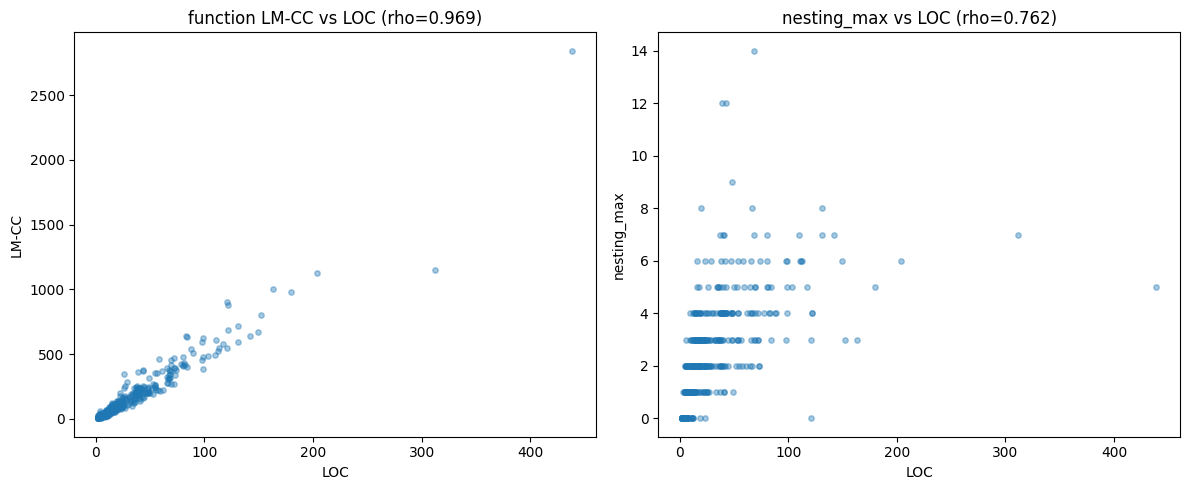

In [9]:
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
r1, _ = spearmanr(clean['lm_cc_score'], clean['loc'])
axes[0].scatter(clean['loc'], clean['lm_cc_score'], alpha=0.4, s=15)
axes[0].set_xlabel('LOC'); axes[0].set_ylabel('LM-CC')
axes[0].set_title(f'function LM-CC vs LOC (rho={r1:.3f})')
r2, _ = spearmanr(clean['nesting_max'], clean['loc'])
axes[1].scatter(clean['loc'], clean['nesting_max'], alpha=0.4, s=15)
axes[1].set_xlabel('LOC'); axes[1].set_ylabel('nesting_max')
axes[1].set_title(f'nesting_max vs LOC (rho={r2:.3f})')
plt.tight_layout(); plt.show()


## All verified agents — resolution rate & per-agent LM-CC

Beyond the single-model label above, the cells below use the per-task **resolution rate** across all 134 verified agents, and end with **Table 1** (one row per agent).

In [10]:
all_predictions = pd.read_parquet(PATHS.ALL_PREDICTIONS)   # [instance_id, model, resolved]

metric_cols = ['lm_cc_score', 'loc', 'cc_sum', 'halstead_volume', 'nesting_max']
long = all_predictions.merge(clean[['instance_id', *metric_cols]], on='instance_id', how='inner')
n_agents = all_predictions['model'].nunique()
print(f'agents: {n_agents}  |  clean tasks: {clean["instance_id"].nunique()}')
print(f'long rows: {len(long):,}  (agents x clean tasks)')
clean['resolution_rate'].describe()


agents: 134  |  clean tasks: 411
long rows: 55,074  (agents x clean tasks)


count    411.000000
mean       0.563387
std        0.297384
min        0.000000
25%        0.354478
50%        0.634328
75%        0.813433
max        0.962687
Name: resolution_rate, dtype: float64

### Task-difficulty distribution

count    411.000000
mean       0.563387
std        0.297384
min        0.000000
25%        0.354478
50%        0.634328
75%        0.813433
max        0.962687
Name: resolution_rate, dtype: float64


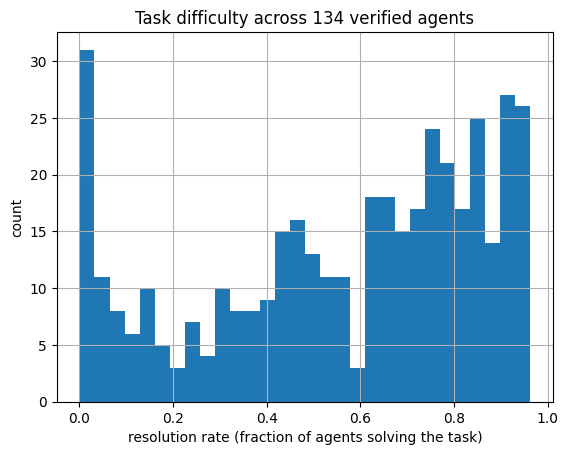

In [11]:
print(clean['resolution_rate'].describe())
clean['resolution_rate'].hist(bins=30)
plt.xlabel('resolution rate (fraction of agents solving the task)')
plt.ylabel('count')
plt.title(f'Task difficulty across {n_agents} verified agents')
plt.show()


### Correlation vs. resolution rate (control = function LOC)

In [12]:
rate_table = full_correlation_table(clean, available_metrics, score='resolution_rate', control='loc')
print('=== Function-level: correlation vs. resolution_rate ===')
print(rate_table.to_string(index=False))


=== Function-level: correlation vs. resolution_rate ===
             metric      sample_zero sample_partial_loc          subgroup_zero   subgroup_partial_loc
             cc_avg +0.019 (p=0.700)   +0.166 (p=0.001)  +0.300 (p=0.433, n=9)  +0.379 (p=0.373, n=9)
             cc_max -0.018 (p=0.723)   +0.144 (p=0.003) +0.139 (p=0.701, n=11) +0.089 (p=0.842, n=10)
             cc_sum -0.076 (p=0.125)   +0.063 (p=0.204)  -0.600 (p=0.088, n=9) -0.000 (p=1.000, n=10)
    halstead_volume -0.084 (p=0.089)   +0.039 (p=0.426)  -0.300 (p=0.433, n=9) -0.173 (p=0.669, n=11)
halstead_difficulty -0.072 (p=0.145)   +0.053 (p=0.281) -0.383 (p=0.308, n=10)  +0.462 (p=0.263, n=9)
    halstead_effort -0.080 (p=0.107)   +0.047 (p=0.342) -0.418 (p=0.229, n=11)  +0.095 (p=0.831, n=9)
                loc -0.123 (p=0.013)                  — -0.618 (p=0.043, n=11)                      —
               lloc -0.115 (p=0.020)   +0.107 (p=0.030)  -0.717 (p=0.030, n=9) -0.000 (p=1.000, n=10)
        nesting_max -0.046

### LM-CC across difficulty tiers

        count        mean  median
tier                             
hard       99  213.519192   109.2
medium    118  145.513559    88.1
easy      194  154.747423    92.2

Kruskal-Wallis across tiers: p = 0.285


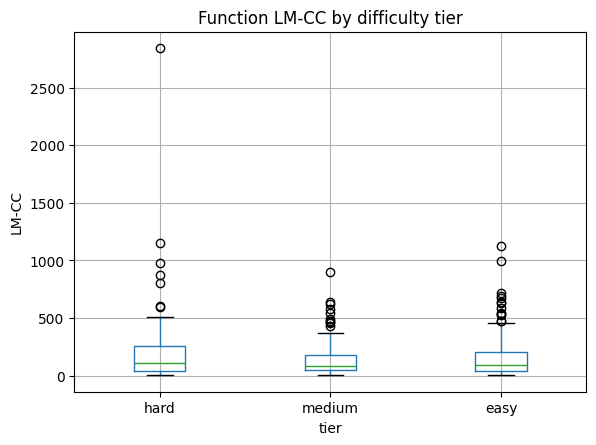

In [13]:
from scipy.stats import kruskal

clean['tier'] = pd.cut(clean['resolution_rate'], bins=[-0.01, 0.33, 0.66, 1.01],
                       labels=['hard', 'medium', 'easy'])
print(clean.groupby('tier', observed=True)['lm_cc_score'].agg(['count', 'mean', 'median']))
groups = [g['lm_cc_score'].values for _, g in clean.groupby('tier', observed=True)]
print(f'\nKruskal-Wallis across tiers: p = {kruskal(*groups).pvalue:.3f}')
clean.boxplot(column='lm_cc_score', by='tier')
plt.suptitle(''); plt.title('Function LM-CC by difficulty tier'); plt.ylabel('LM-CC')
plt.show()


## Table 1 — function-level LM-CC across all agents

One row per agent: resolve rate + the four correlation flavours of function LM-CC vs that agent's `resolved`.

In [14]:
from src.correlation import per_agent_correlation_table

table1 = per_agent_correlation_table(long, metric='lm_cc_score', score='resolved', control='loc')

def _short(name):
    return name.split('_', 1)[1] if name[:8].isdigit() else name

show = table1.copy()
show['agent'] = show['agent'].map(_short)
show['resolve_rate'] = (show['resolve_rate'] * 100).round(1).astype(str) + ' %'
for col in ['sample_zero', 'sample_partial_loc', 'subgroup_zero', 'subgroup_partial_loc']:
    show[col] = show[col].map(lambda v: f'{v:+.3f}')
print(f'Table 1 - function-level LM-CC across all {len(table1)} verified agents')
print(show.to_string(index=False))


Table 1 - function-level LM-CC across all 134 verified agents
                                                     agent resolve_rate sample_zero sample_partial_loc subgroup_zero subgroup_partial_loc
                    sonar-foundation-agent_claude-opus-4-5       84.7 %      -0.001             -0.003        -0.133               -0.000
                              livesweagent_claude-opus-4-5       83.7 %      +0.013             +0.033        +0.192               +0.000
                                     trae_doubao_seed_code       83.7 %      +0.008             +0.011        -0.055               -0.000
                                                    ACoder       83.2 %      -0.026             +0.002        -0.170               -0.000
                                 openhands_claude-opus-4-5       82.7 %      +0.020             -0.004        +0.268               +0.000
                                        atlassian-rovo-dev       82.2 %      +0.019             +0.063        

In [15]:
# Top 10 agents where function LM-CC best predicts failure (most negative sample_zero)
ranking = table1.sort_values('sample_zero').head(10).copy()
ranking.insert(0, 'rank', range(1, len(ranking) + 1))
ranking['agent'] = ranking['agent'].map(_short)
ranking['resolve_rate'] = (ranking['resolve_rate'] * 100).round(1).astype(str) + ' %'
for col in ['sample_zero', 'sample_partial_loc', 'subgroup_zero', 'subgroup_partial_loc']:
    ranking[col] = ranking[col].map(lambda v: f'{v:+.3f}')
print('Top 10 agents by strongest negative function-LM-CC correlation (sample_zero)')
print(ranking.to_string(index=False))


Top 10 agents by strongest negative function-LM-CC correlation (sample_zero)
 rank                                                      agent resolve_rate sample_zero sample_partial_loc subgroup_zero subgroup_partial_loc
    1                                         factory_code_droid       41.6 %      -0.191             -0.051        -0.950               -0.000
    2                                            sweagent_lm_32b       44.5 %      -0.164             +0.002        -0.817               -0.000
    3                                                     solver       47.9 %      -0.160             +0.061        -0.733               -0.000
    4                      amazon-q-developer-agent-20240430-dev       27.0 %      -0.154             -0.037        -0.752               -0.000
    5                               sweagent_devstral_small_2507       42.6 %      -0.144             -0.010        -0.799               -0.000
    6                            lingma-agent_lingma-swe-gp